<a href="https://colab.research.google.com/github/GAnu1712/AI-ML-Training/blob/main/Asses2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession

# Create a Spark session
spark = SparkSession.builder.appName("TitanicEDA").getOrCreate()

# Load Titanic dataset
file_path = "/content/titanic.csv"  # Replace with your dataset's path
titanic_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Show a preview of the data
titanic_df.show(5)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
+-----------+--------+------+--------------------+------+----+-----+-----+------

In [ ]:
# Schema of the dataset
titanic_df.printSchema()

# Basic statistics of numeric columns
titanic_df.describe().show()

# Count passengers by survival status
titanic_df.groupBy("Survived").count().show()

# Count passengers by class
titanic_df.groupBy("Pclass").count().show()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)

+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|      PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+-----------------+-------------------+------------------+--------------------+------+------------------+--------------

In [ ]:
# Convert PySpark DataFrame to Pandas
titanic_pandas_df = titanic_df.toPandas()

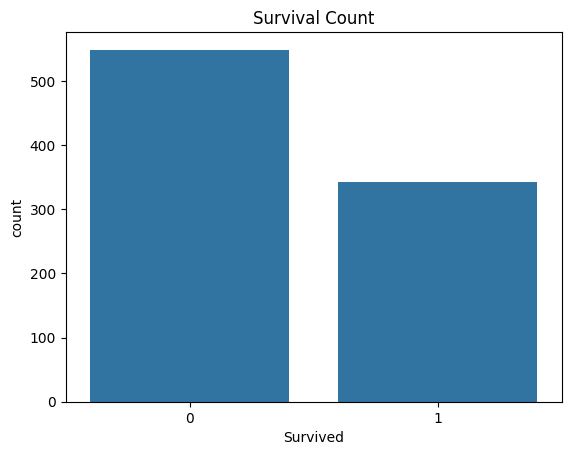

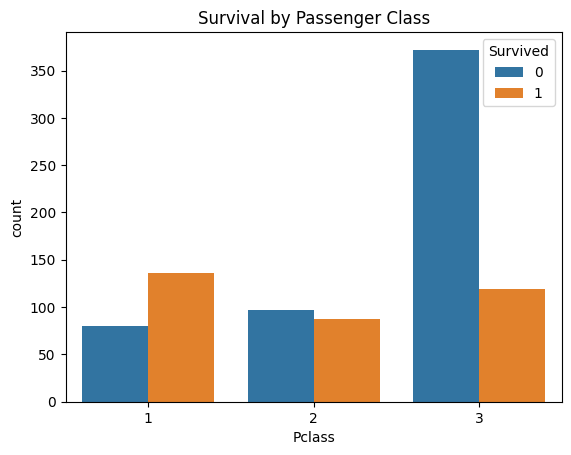

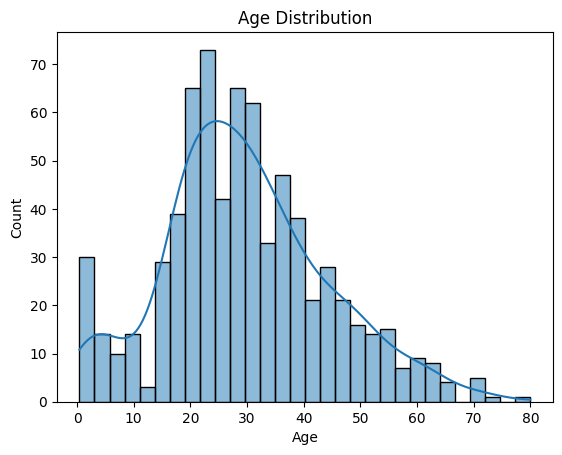

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Survival count plot
sns.countplot(data=titanic_pandas_df, x="Survived")
plt.title("Survival Count")
plt.show()

# Survival by Passenger Class
sns.countplot(data=titanic_pandas_df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

# Age distribution
sns.histplot(titanic_pandas_df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
import plotly.express as px

# Survival by Sex
fig = px.bar(titanic_pandas_df, x="Sex", color="Survived", title="Survival by Gender")
fig.show()

# Age vs Fare colored by Survival
fig = px.scatter(titanic_pandas_df, x="Age", y="Fare", color="Survived", title="Age vs Fare by Survival")
fig.show()